# Preproceso 2

Predecir el CO2 en función del resto

In [147]:
from pathlib import Path

# Encontramos los paths para los datos
root = Path('..').resolve() # ruta absoluta

data = root / "data"
data_raw = data / "raw"

# ref_path = data_raw / "data_ref_until_2020-02-13.csv"
gas_path = data_raw / "database_gas.csv"
pos_path = data_raw / "database_pos.csv"

In [148]:
import pandas as pd

tipos_gas = {
    'CO2CosIRValue': 'uint16',
    'CO2MG811Value': 'uint16',
    'MOX1': 'uint16',
    'MOX2': 'uint16',
    'MOX3': 'uint16',
    'MOX4': 'uint16',
    'COValue': 'uint16'
}

# Creamos los dataframes
raw_gas = pd.read_csv(gas_path, dtype=tipos_gas, parse_dates=['timestamp'])
pos = pd.read_csv(pos_path, parse_dates=['datetime'])
pos = pos.fillna(0.0)

In [149]:
features = ["timestamp","temperature", "CO2CosIRValue","humidity", "MOX1", "MOX2", "MOX3", "MOX4", "COValue"]

target = ["CO2MG811Value"]

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(raw_gas[features], raw_gas[target], test_size=0.2, shuffle=True, random_state=314159)

gas = pd.DataFrame(X_train)
gas["CO2MG811Value"] = y_train

gas

,timestamp,temperature,CO2CosIRValue,humidity,MOX1,MOX2,MOX3,MOX4,COValue,CO2MG811Value
83996,2019-11-25 22:16:59.066558+01:00,24.81,119,47.26,407,695,651,570,131,572
236551,2019-12-31 21:35:07.327725+01:00,24.59,147,45.79,437,634,571,496,225,507
103005,2019-11-30 07:56:53.332265+01:00,19.85,129,55.66,482,728,678,616,106,563
258422,2020-01-05 23:05:21.931479+01:00,22.60,107,43.85,494,691,635,573,133,512
47339,2019-11-17 10:37:20.394228+01:00,16.68,82,48.26,556,779,744,691,84,609
...,...,...,...,...,...,...,...,...,...,...
10577,2019-11-08 22:23:06.638343+01:00,24.90,104,45.86,411,707,665,578,115,599
253568,2020-01-04 20:07:23.184636+01:00,20.88,111,47.42,500,710,669,606,134,512
89762,2019-11-27 06:22:37.010051+01:00,19.27,141,56.89,423,724,681,605,119,564
150271,2019-12-11 22:06:03.223367+01:00,23.08,110,47.02,480,734,685,625,108,551


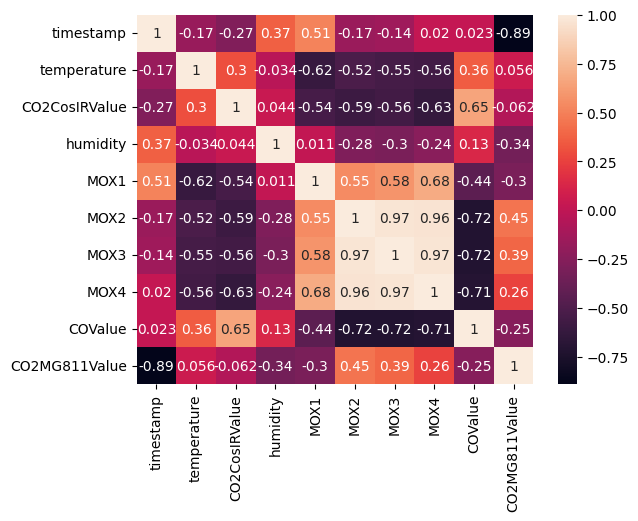

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(gas[features+target].corr(), annot=True)

plt.show()

In [152]:
gas.describe()

,temperature,CO2CosIRValue,humidity,MOX1,MOX2,MOX3,MOX4,COValue,CO2MG811Value
count,332922.000000,332922.000000,332922.000000,332922.000000,332922.000000,332922.000000,332922.000000,332922.000000,332922.000000
mean,20.115341,102.476478,52.239088,500.236848,718.661119,672.725413,609.370240,120.146635,539.071626
std,2.297207,38.947430,4.340014,49.807465,31.305191,36.366266,42.713728,35.921000,34.925182
min,13.530000,21.000000,38.160000,262.000000,514.000000,447.000000,355.000000,74.000000,408.000000
25%,18.640000,76.000000,49.060000,468.000000,703.000000,655.000000,587.000000,103.000000,510.000000
50%,20.100000,105.000000,52.310000,502.000000,719.000000,674.000000,611.000000,113.000000,528.000000
75%,21.630000,117.000000,55.630000,536.000000,738.000000,693.000000,635.000000,128.000000,563.000000
max,26.140000,591.000000,69.260000,626.000000,808.000000,777.000000,727.000000,918.000000,632.000000


# Detección de outliers

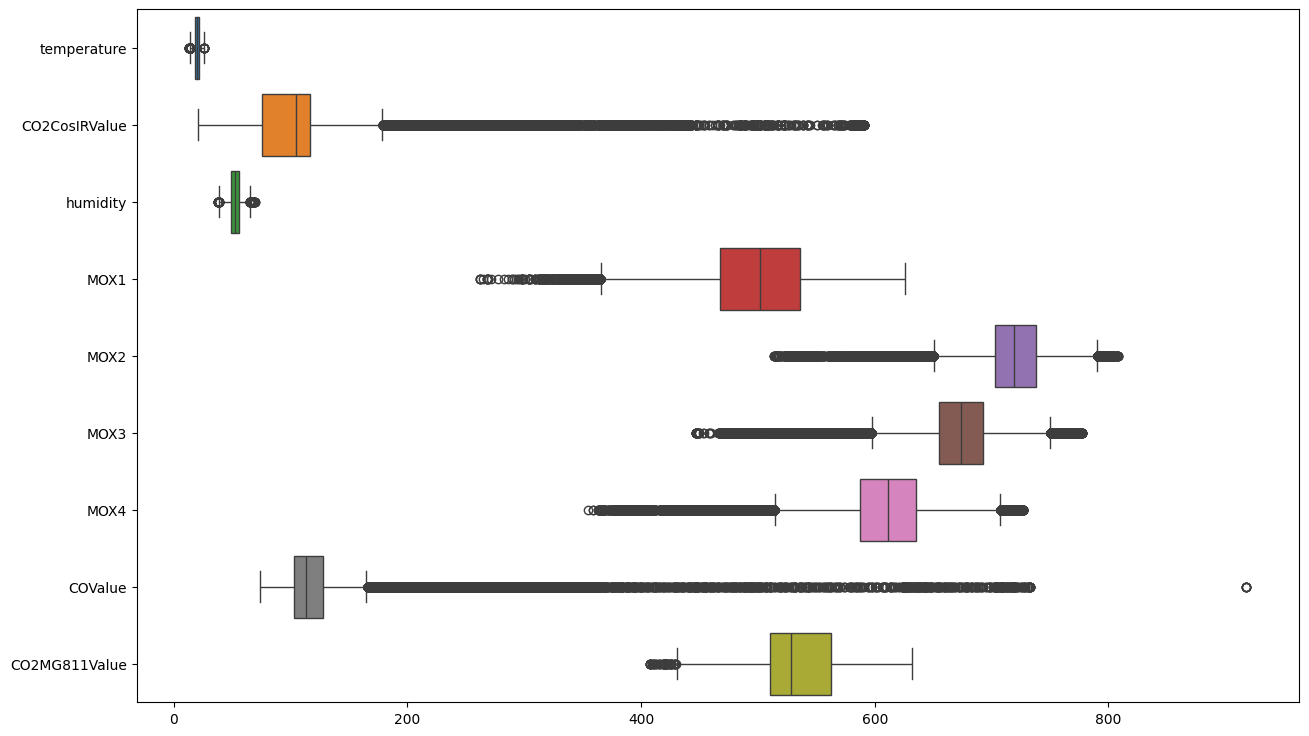

In [153]:
plt.figure(figsize=(15,9))
sns.boxplot(gas, orient="h")
plt.show()

In [154]:
gas_sin_navidad = gas[~gas['timestamp'].between('2019-12-24', '2019-12-25')]

In [155]:
gas_sin_navidad

,timestamp,temperature,CO2CosIRValue,humidity,MOX1,MOX2,MOX3,MOX4,COValue,CO2MG811Value
83996,2019-11-25 22:16:59.066558+01:00,24.81,119,47.26,407,695,651,570,131,572
236551,2019-12-31 21:35:07.327725+01:00,24.59,147,45.79,437,634,571,496,225,507
103005,2019-11-30 07:56:53.332265+01:00,19.85,129,55.66,482,728,678,616,106,563
258422,2020-01-05 23:05:21.931479+01:00,22.60,107,43.85,494,691,635,573,133,512
47339,2019-11-17 10:37:20.394228+01:00,16.68,82,48.26,556,779,744,691,84,609
...,...,...,...,...,...,...,...,...,...,...
10577,2019-11-08 22:23:06.638343+01:00,24.90,104,45.86,411,707,665,578,115,599
253568,2020-01-04 20:07:23.184636+01:00,20.88,111,47.42,500,710,669,606,134,512
89762,2019-11-27 06:22:37.010051+01:00,19.27,141,56.89,423,724,681,605,119,564
150271,2019-12-11 22:06:03.223367+01:00,23.08,110,47.02,480,734,685,625,108,551


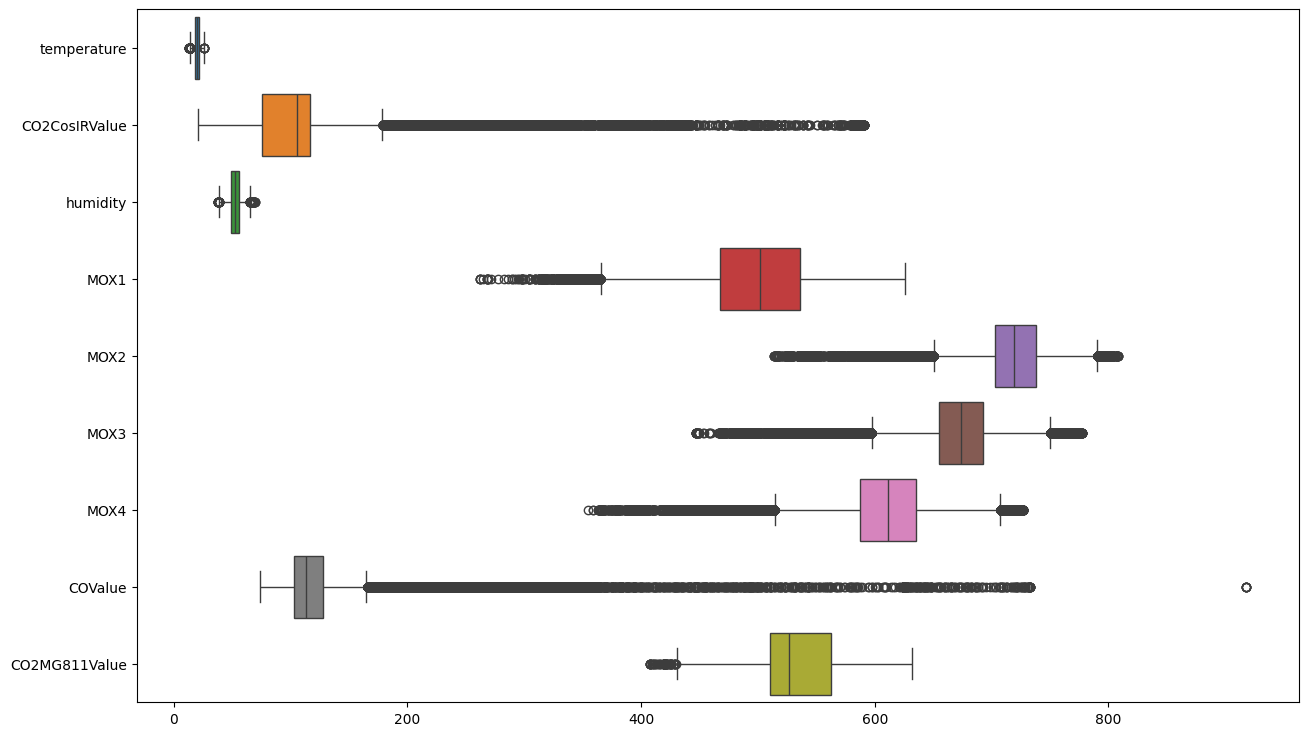

In [156]:
plt.figure(figsize=(15,9))
sns.boxplot(gas_sin_navidad, orient="h")
plt.show()

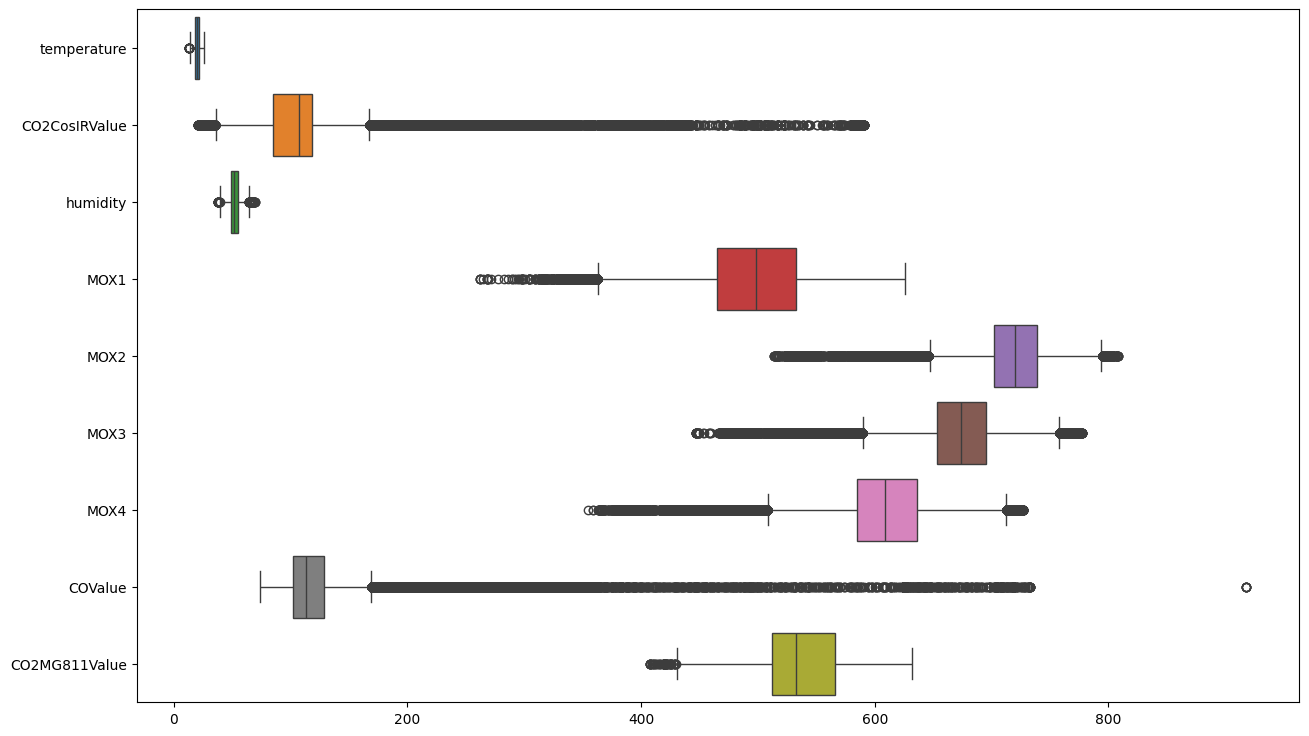

In [157]:
gas_fechas_nadie = gas[~gas['timestamp'].between('2020-01-27', '2020-02-02')]

plt.figure(figsize=(15,9))
sns.boxplot(gas_fechas_nadie, orient="h")
plt.show()

## Outliers univariantes

In [158]:
import numpy as np

def contar_outliers_iqr(df, columna):
    """
    Cuenta la cantidad de outliers en una columna de un DataFrame
    usando el método del Rango Intercuartílico (IQR).
    """
    # 1. Calcular el primer cuartil (25%) y el tercer cuartil (75%)
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    
    # 2. Calcular el IQR (Rango Intercuartílico)
    IQR = Q3 - Q1
    
    # 3. Definir los límites (usando el factor estándar de 1.5)
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # 4. Filtrar los datos que están fuera de los límites
    filtro_outliers = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    cantidad_outliers = filtro_outliers.sum()
    
    # Opcional: Imprimir detalles para referencia
    print(f"Variable: {columna}")
    print(f"Límites: < {limite_inferior:.2f} y > {limite_superior:.2f}")
    print(f"Outliers encontrados: {cantidad_outliers}")
    
    return cantidad_outliers

for i in gas.columns:
    contar_outliers_iqr(gas, i)

Variable: timestamp
Límites: < .2f y > .2f
Outliers encontrados: 0
Variable: temperature
Límites: < 14.16 y > 26.11
Outliers encontrados: 520
Variable: CO2CosIRValue
Límites: < 14.50 y > 178.50
Outliers encontrados: 6176
Variable: humidity
Límites: < 39.20 y > 65.48
Outliers encontrados: 107
Variable: MOX1
Límites: < 366.00 y > 638.00
Outliers encontrados: 2748
Variable: MOX2
Límites: < 650.50 y > 790.50
Outliers encontrados: 12926
Variable: MOX3
Límites: < 598.00 y > 750.00
Outliers encontrados: 17300
Variable: MOX4
Límites: < 515.00 y > 707.00
Outliers encontrados: 12233
Variable: COValue
Límites: < 65.50 y > 165.50
Outliers encontrados: 17378
Variable: CO2MG811Value
Límites: < 430.50 y > 642.50
Outliers encontrados: 58


La distribución del gas no es Normal el método IQR 

In [159]:
gas.columns

Index(['timestamp', 'temperature', 'CO2CosIRValue', 'humidity', 'MOX1', 'MOX2',
       'MOX3', 'MOX4', 'COValue', 'CO2MG811Value'],
      dtype='object')

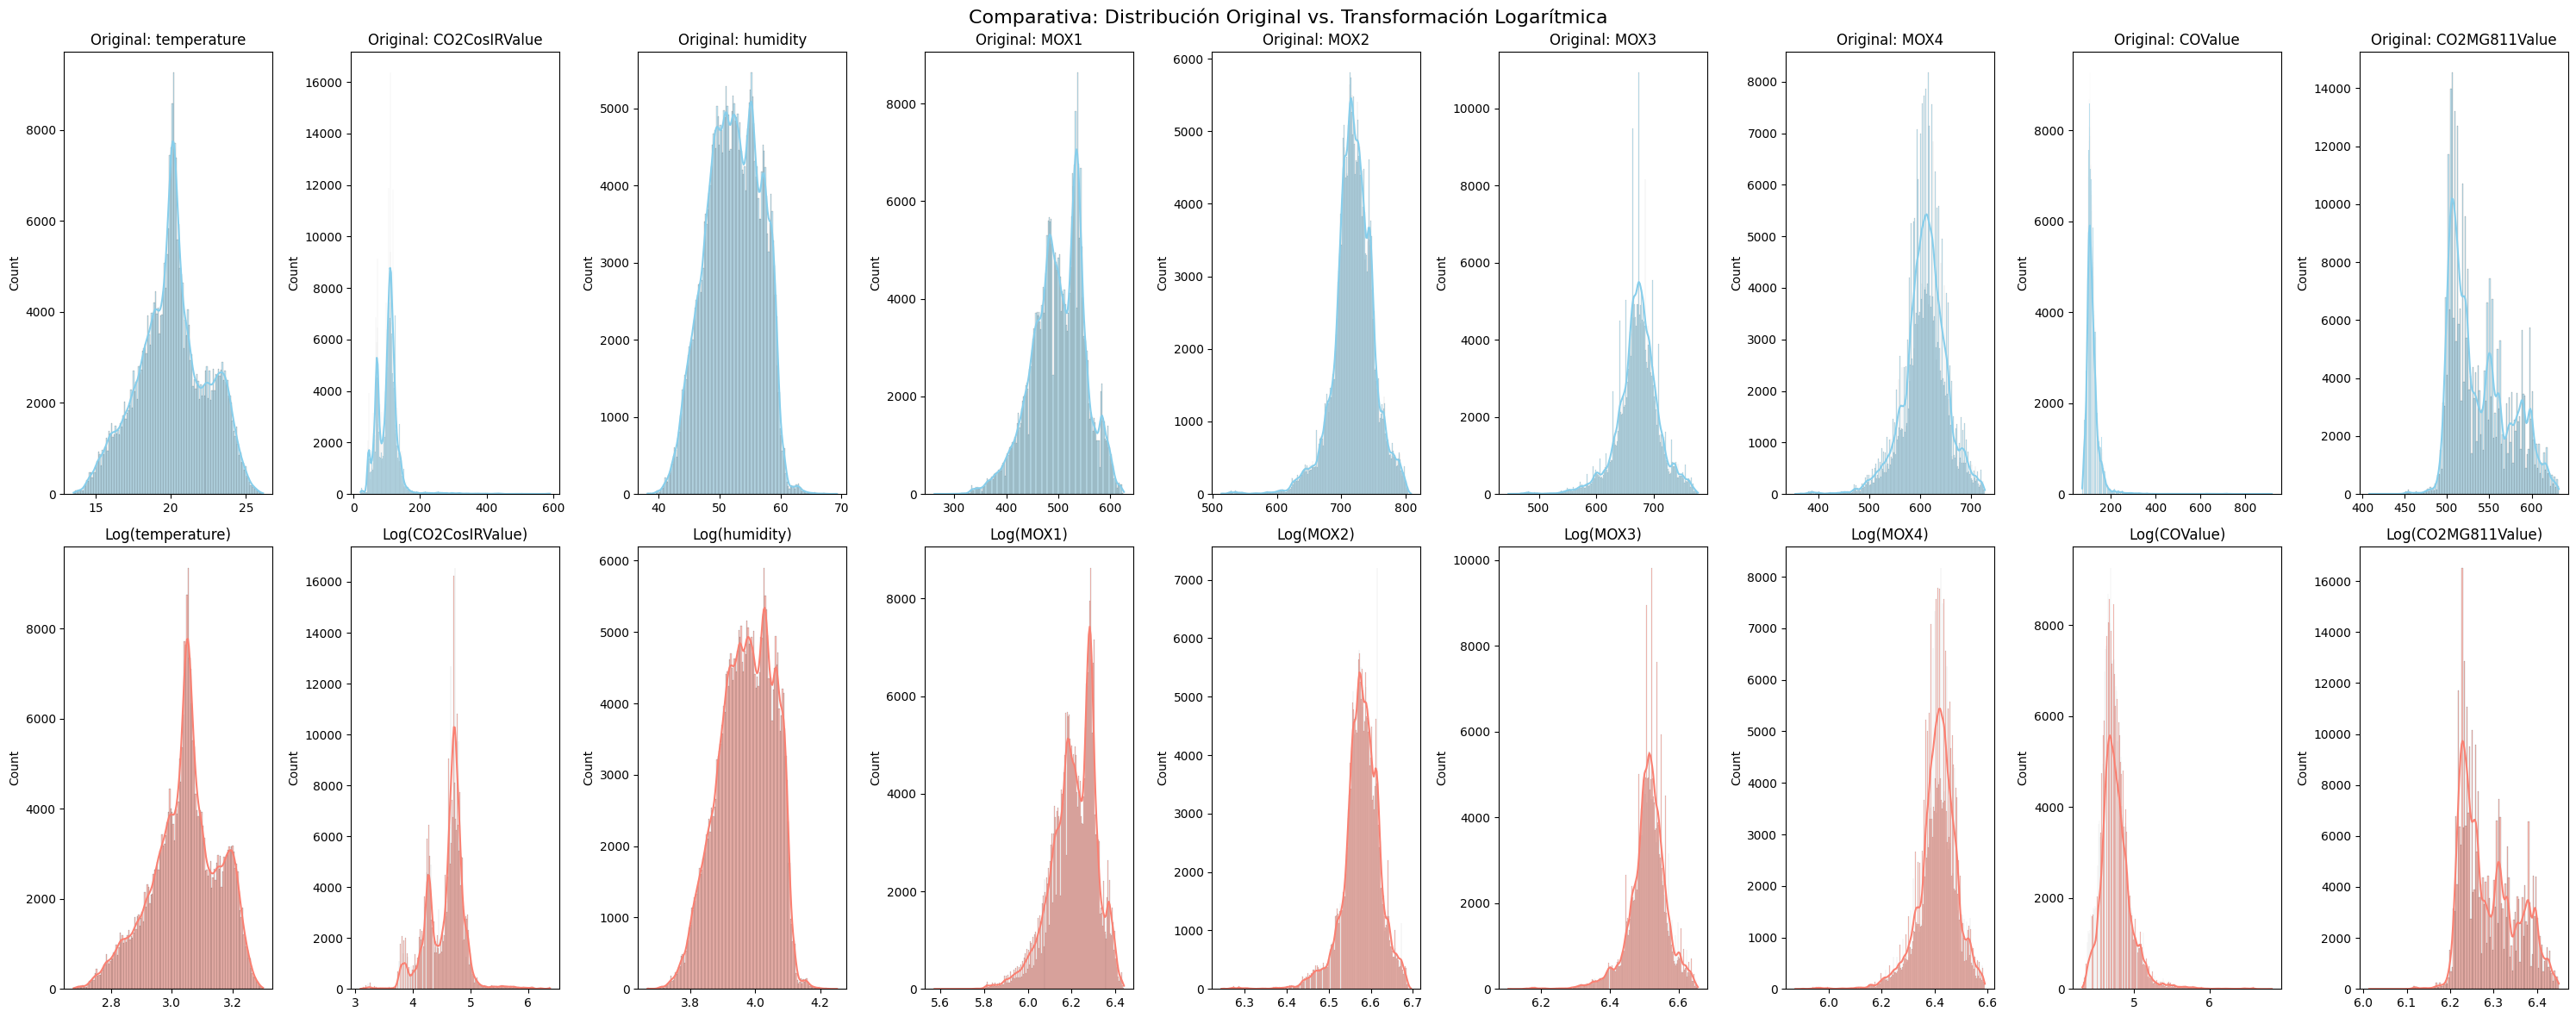

In [160]:
# Comparativa: Datos Originales vs Logaritmo

df = gas.drop(columns=["timestamp"])
variables_num = df.columns

fig, axes = plt.subplots(2, 9, figsize=(30, 12))
fig.suptitle('Comparativa: Distribución Original vs. Transformación Logarítmica', fontsize=16)

# Histogramas originales
for i, col in enumerate(variables_num):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'Original: {col}')
    axes[0, i].set_xlabel('')

# Histogramas con logaritmo
for i, col in enumerate(variables_num):
    log_data = np.log1p(df[col])
    sns.histplot(log_data, kde=True, ax=axes[1, i], color='salmon')
    axes[1, i].set_title(f'Log({col})')
    axes[1, i].set_xlabel('')

plt.tight_layout()
plt.show()

## Outliers multivariantes

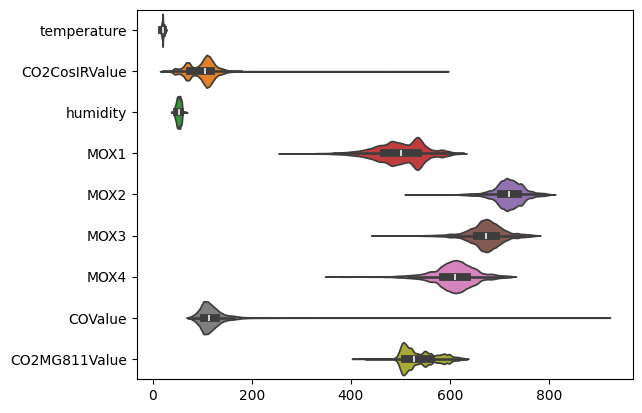

In [161]:
sns.violinplot(gas, orient="h")
plt.show()

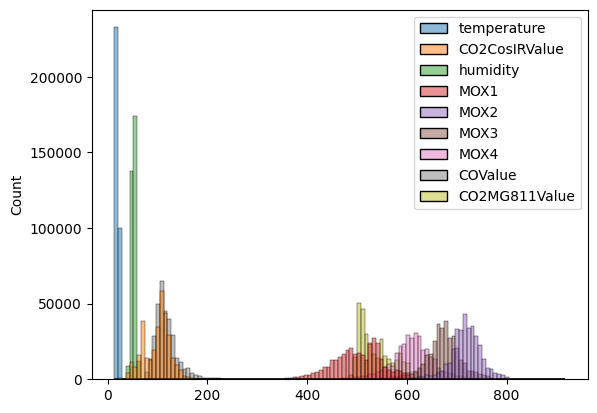

In [162]:
sns.histplot(gas)
plt.show()

In [163]:
gas[gas['COValue'] > 800] # Parece que hubo un problema con el sensor

,timestamp,temperature,CO2CosIRValue,humidity,MOX1,MOX2,MOX3,MOX4,COValue,CO2MG811Value
377486,2020-02-04 12:30:28.950446+01:00,16.97,99,64.51,364,791,729,619,918,420
377485,2020-02-04 12:30:08.919494+01:00,16.97,99,64.51,364,791,729,615,918,421
377482,2020-02-04 12:29:09.705907+01:00,16.97,96,64.51,364,791,725,606,918,421
377484,2020-02-04 12:29:48.830306+01:00,16.97,98,64.51,364,791,728,609,918,421
377483,2020-02-04 12:29:28.817307+01:00,16.97,96,64.51,364,791,726,608,918,421
377481,2020-02-04 12:28:51.158730+01:00,16.97,94,64.51,364,790,725,606,918,421


In [164]:
gas_sin_outliers = gas[~gas['COValue'] > 800].drop(columns=['timestamp'])

In [165]:
gas_sin_outliers

,temperature,CO2CosIRValue,humidity,MOX1,MOX2,MOX3,MOX4,COValue,CO2MG811Value
83996,24.81,119,47.26,407,695,651,570,131,572
236551,24.59,147,45.79,437,634,571,496,225,507
103005,19.85,129,55.66,482,728,678,616,106,563
258422,22.60,107,43.85,494,691,635,573,133,512
47339,16.68,82,48.26,556,779,744,691,84,609
...,...,...,...,...,...,...,...,...,...
10577,24.90,104,45.86,411,707,665,578,115,599
253568,20.88,111,47.42,500,710,669,606,134,512
89762,19.27,141,56.89,423,724,681,605,119,564
150271,23.08,110,47.02,480,734,685,625,108,551


## Discretizar

In [171]:
from sklearn.preprocessing import KBinsDiscretizer

discretizer = KBinsDiscretizer(n_bins=5, encode="ordinal", quantile_method="inverted_cdf")

CO2 = discretizer.fit_transform(gas_sin_outliers[target]).astype(int)
gas_sin_outliers_discretizado = gas_sin_outliers.copy()
gas_sin_outliers_discretizado[target] = CO2

In [172]:
gas_sin_outliers_discretizado

,temperature,CO2CosIRValue,humidity,MOX1,MOX2,MOX3,MOX4,COValue,CO2MG811Value
83996,24.81,119,47.26,407,695,651,570,131,3
236551,24.59,147,45.79,437,634,571,496,225,1
103005,19.85,129,55.66,482,728,678,616,106,3
258422,22.60,107,43.85,494,691,635,573,133,1
47339,16.68,82,48.26,556,779,744,691,84,4
...,...,...,...,...,...,...,...,...,...
10577,24.90,104,45.86,411,707,665,578,115,4
253568,20.88,111,47.42,500,710,669,606,134,1
89762,19.27,141,56.89,423,724,681,605,119,3
150271,23.08,110,47.02,480,734,685,625,108,3


In [176]:
y_test_discretizado = discretizer.transform(y_test).astype(int)

gas_test = pd.DataFrame(X_test)
gas_test[target] = y_test_discretizado

gas_test

,timestamp,temperature,CO2CosIRValue,humidity,MOX1,MOX2,MOX3,MOX4,COValue,CO2MG811Value
345482,2020-01-26 03:29:37.202770+01:00,15.65,73,58.35,582,745,708,662,104,1
228256,2019-12-29 23:30:09.939204+01:00,22.31,116,47.43,516,712,671,609,128,2
172426,2019-12-17 01:14:38.579000+01:00,21.88,124,54.46,483,694,621,566,151,2
261038,2020-01-06 13:37:20.932692+01:00,15.12,69,49.16,596,766,733,680,89,2
312742,2020-01-18 12:58:02.104825+01:00,16.66,65,42.06,573,769,736,675,91,1
...,...,...,...,...,...,...,...,...,...,...
230251,2019-12-30 10:35:09.116936+01:00,18.86,122,53.17,531,730,686,636,120,2
21783,2019-11-11 12:38:24.240430+01:00,17.10,60,42.32,608,799,771,722,78,4
342240,2020-01-25 08:54:28.500141+01:00,16.90,61,48.01,592,763,731,687,83,1
314100,2020-01-18 20:30:41.482253+01:00,21.49,116,46.30,505,699,661,596,123,0


In [179]:
gas_sin_outliers_discretizado.to_csv("gas_train.csv", index=False)
gas_test.drop(columns=['timestamp']).to_csv("gas_test.csv", index=False)